In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set publication style aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 150

# Load authentic Superstore dataset
DATA_URL = "https://raw.githubusercontent.com/hifza-anjum/TSF-Internship/main/SampleSuperstore.csv"

print("Loading Superstore E-Commerce dataset...")
df = pd.read_csv(DATA_URL)

print(f"Dataset Loaded Successfully! Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\n--- First 5 Transactions ---")
df.head()

Loading Superstore E-Commerce dataset...
Dataset Loaded Successfully! Rows: 9994, Columns: 13

--- First 5 Transactions ---


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [12]:
# 1. Check for missing values and duplicates
print("--- Missing Values ---")
print(df.isnull().sum())

duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows Found: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Purged {duplicates} duplicate rows. Remaining clean rows: {len(df)}")

# 2. Engineer Profit Margin (%)
df['Profit_Margin'] = (df['Profit'] / df['Sales']) * 100

# 3. Summary Statistics for Key Metrics
print("\n--- Key Financial Metrics Summary ---")
summary = df[['Sales', 'Quantity', 'Discount', 'Profit', 'Profit_Margin']].describe().T
summary[['mean', 'std', 'min', '50%', 'max']]

--- Missing Values ---
Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

Duplicate Rows Found: 17
Purged 17 duplicate rows. Remaining clean rows: 9977

--- Key Financial Metrics Summary ---


,mean,std,min,50%,max
Sales,230.148902,623.721409,0.444,54.816,22638.480
Quantity,3.790719,2.226657,1.000,3.000,14.000
Discount,0.156278,0.206455,0.000,0.200,0.800
Profit,28.690130,234.457840,-6599.978,8.671,8399.976
Profit_Margin,12.011354,46.663769,-275.000,27.000,50.000


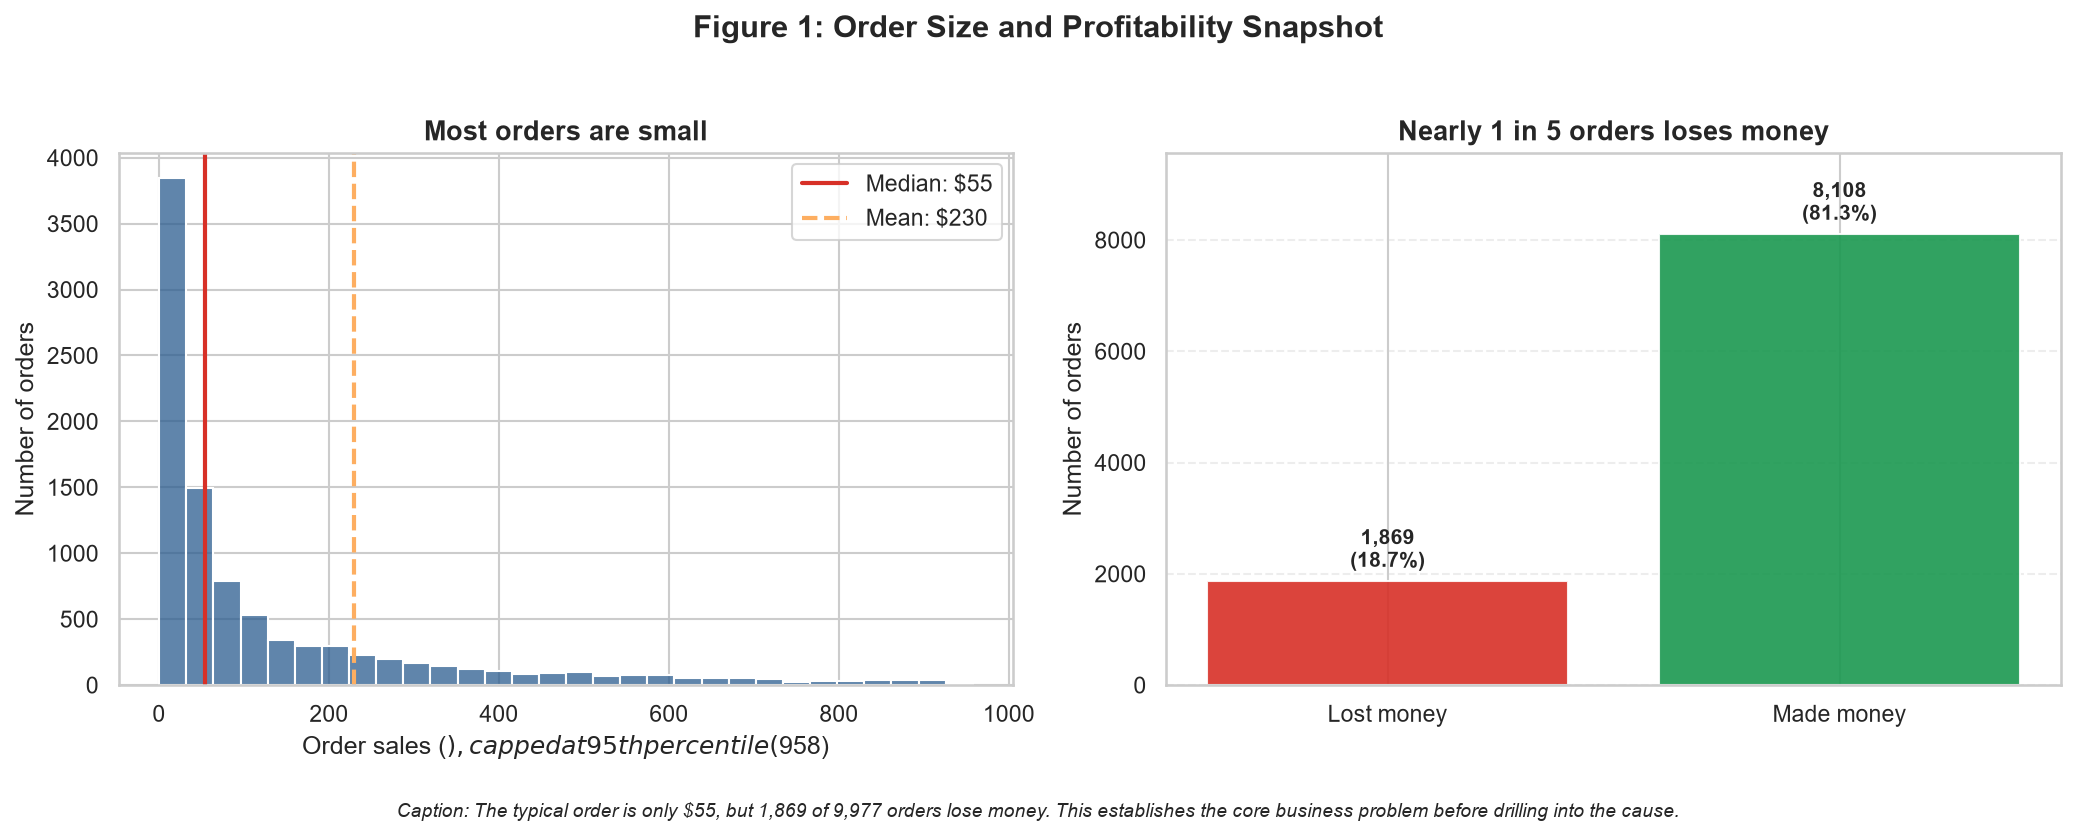

In [13]:
# Figure 1: simple overview of order size and profit status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sales_cap = df['Sales'].quantile(0.95)
median_sales = df['Sales'].median()
mean_sales = df['Sales'].mean()
loss_orders = (df['Profit'] < 0).sum()
profitable_orders = (df['Profit'] >= 0).sum()
total_orders = len(df)

# Left: most orders are small, so cap the x-axis at the 95th percentile for readability
sns.histplot(df.loc[df['Sales'] <= sales_cap, 'Sales'], bins=30, ax=axes[0], color='#2b5c8f')
axes[0].axvline(median_sales, color='#d73027', linewidth=2, label=f'Median: ${median_sales:,.0f}')
axes[0].axvline(mean_sales, color='#fdae61', linewidth=2, linestyle='--', label=f'Mean: ${mean_sales:,.0f}')
axes[0].set_title('Most orders are small', fontsize=13, fontweight='bold')
axes[0].set_xlabel(f'Order sales ($), capped at 95th percentile (${sales_cap:,.0f})')
axes[0].set_ylabel('Number of orders')
axes[0].legend(frameon=True)

# Right: directly show how many orders make or lose money
status_labels = ['Lost money', 'Made money']
status_counts = [loss_orders, profitable_orders]
status_colors = ['#d73027', '#1a9850']
bars = axes[1].bar(status_labels, status_counts, color=status_colors, alpha=0.9)
axes[1].set_title('Nearly 1 in 5 orders loses money', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of orders')
axes[1].grid(axis='y', linestyle='--', alpha=0.35)

for bar, count in zip(bars, status_counts):
    pct = count / total_orders * 100
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + total_orders * 0.015,
                 f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[1].set_ylim(0, max(status_counts) * 1.18)

plt.suptitle('Figure 1: Order Size and Profitability Snapshot', fontsize=15, fontweight='bold', y=1.03)
plt.figtext(0.5, -0.04,
            f'Caption: The typical order is only ${median_sales:,.0f}, but {loss_orders:,} of {total_orders:,} orders lose money. '
            'This establishes the core business problem before drilling into the cause.',
            wrap=True, horizontalalignment='center', fontsize=9, style='italic')
plt.tight_layout()
plt.show()


--- Total Sales, Profit & Margin by Category ---
       Category Total_Sales Total_Profit Profit_Margin_Pct
Office Supplies    $718,735     $122,365             17.0%
      Furniture    $741,306      $18,422              2.5%
     Technology    $836,154     $145,455             17.4%


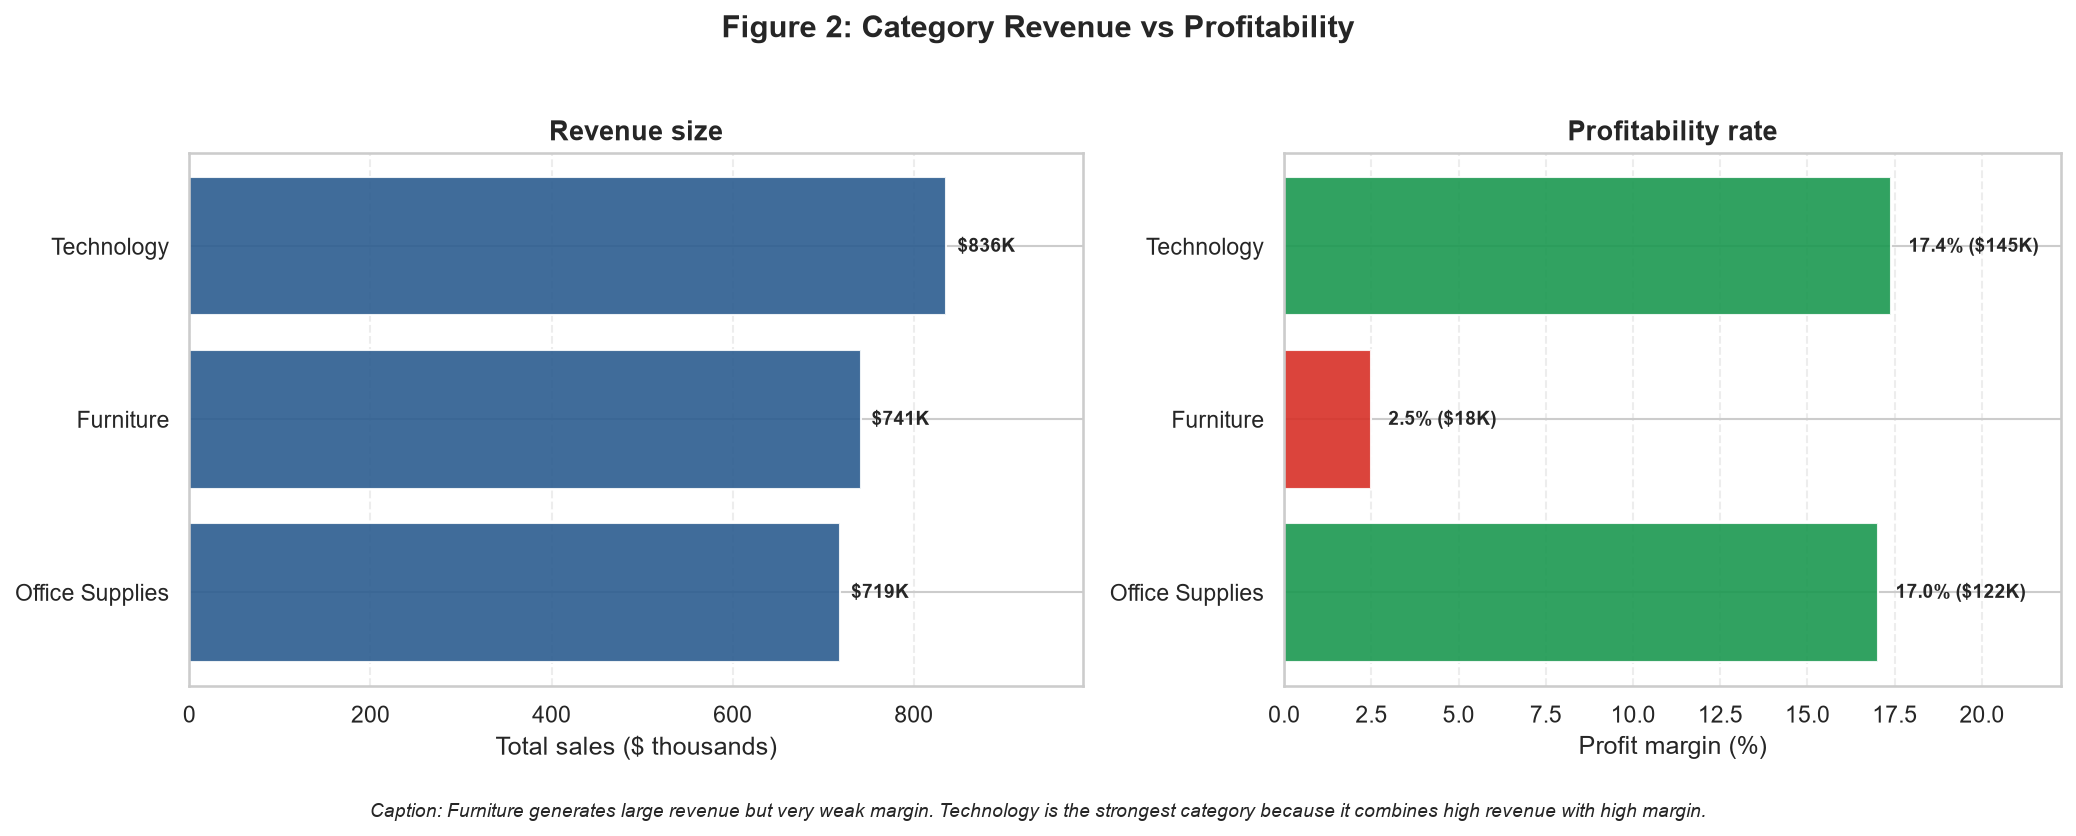

In [14]:
# Figure 2: separate revenue size from profitability rate so the message is easier to see
cat_summary = df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()
cat_summary['Profit_Margin_Pct'] = cat_summary['Total_Profit'] / cat_summary['Total_Sales'] * 100
cat_summary = cat_summary.sort_values('Total_Sales', ascending=True)

print('--- Total Sales, Profit & Margin by Category ---')
print(cat_summary.to_string(index=False, formatters={
    'Total_Sales': '${:,.0f}'.format,
    'Total_Profit': '${:,.0f}'.format,
    'Profit_Margin_Pct': '{:.1f}%'.format
}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1.15, 1]})

# Left: total revenue by category
sales_bars = axes[0].barh(cat_summary['Category'], cat_summary['Total_Sales'] / 1000,
                          color='#2b5c8f', alpha=0.9)
axes[0].set_title('Revenue size', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total sales ($ thousands)')
axes[0].set_ylabel('')
axes[0].grid(axis='x', linestyle='--', alpha=0.35)
for bar, value in zip(sales_bars, cat_summary['Total_Sales']):
    axes[0].text(bar.get_width() + 12, bar.get_y() + bar.get_height()/2,
                 f'${value/1000:.0f}K', va='center', fontsize=9, fontweight='bold')
axes[0].set_xlim(0, (cat_summary['Total_Sales'].max() / 1000) * 1.18)

# Right: profit margin by category
margin_colors = ['#d73027' if v < 5 else '#fdae61' if v < 10 else '#1a9850'
                 for v in cat_summary['Profit_Margin_Pct']]
margin_bars = axes[1].barh(cat_summary['Category'], cat_summary['Profit_Margin_Pct'],
                           color=margin_colors, alpha=0.9)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Profitability rate', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Profit margin (%)')
axes[1].set_ylabel('')
axes[1].grid(axis='x', linestyle='--', alpha=0.35)
for bar, margin, profit in zip(margin_bars, cat_summary['Profit_Margin_Pct'], cat_summary['Total_Profit']):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{margin:.1f}% (${profit/1000:.0f}K)', va='center', fontsize=9, fontweight='bold')
axes[1].set_xlim(0, cat_summary['Profit_Margin_Pct'].max() * 1.28)

plt.suptitle('Figure 2: Category Revenue vs Profitability', fontsize=15, fontweight='bold', y=1.03)
plt.figtext(0.5, -0.04,
            'Caption: Furniture generates large revenue but very weak margin. Technology is the strongest category because it combines high revenue with high margin.',
            wrap=True, horizontalalignment='center', fontsize=9, style='italic')
plt.tight_layout()
plt.show()


Discount tipping point where margin crosses zero: ~22.9%

--- Discount Bucket Summary ---
Discount_Bucket Avg_Margin  Order_Count Loss_Rate
             0%      34.0%         4787      0.0%
          1-10%      15.6%           94      4.3%
         11-20%      17.5%         3705     14.0%
         21-30%     -11.6%          226     91.6%
         31-40%     -21.7%          233     88.8%
         41-50%     -53.6%           77    100.0%
         51-80%    -113.8%          855    100.0%


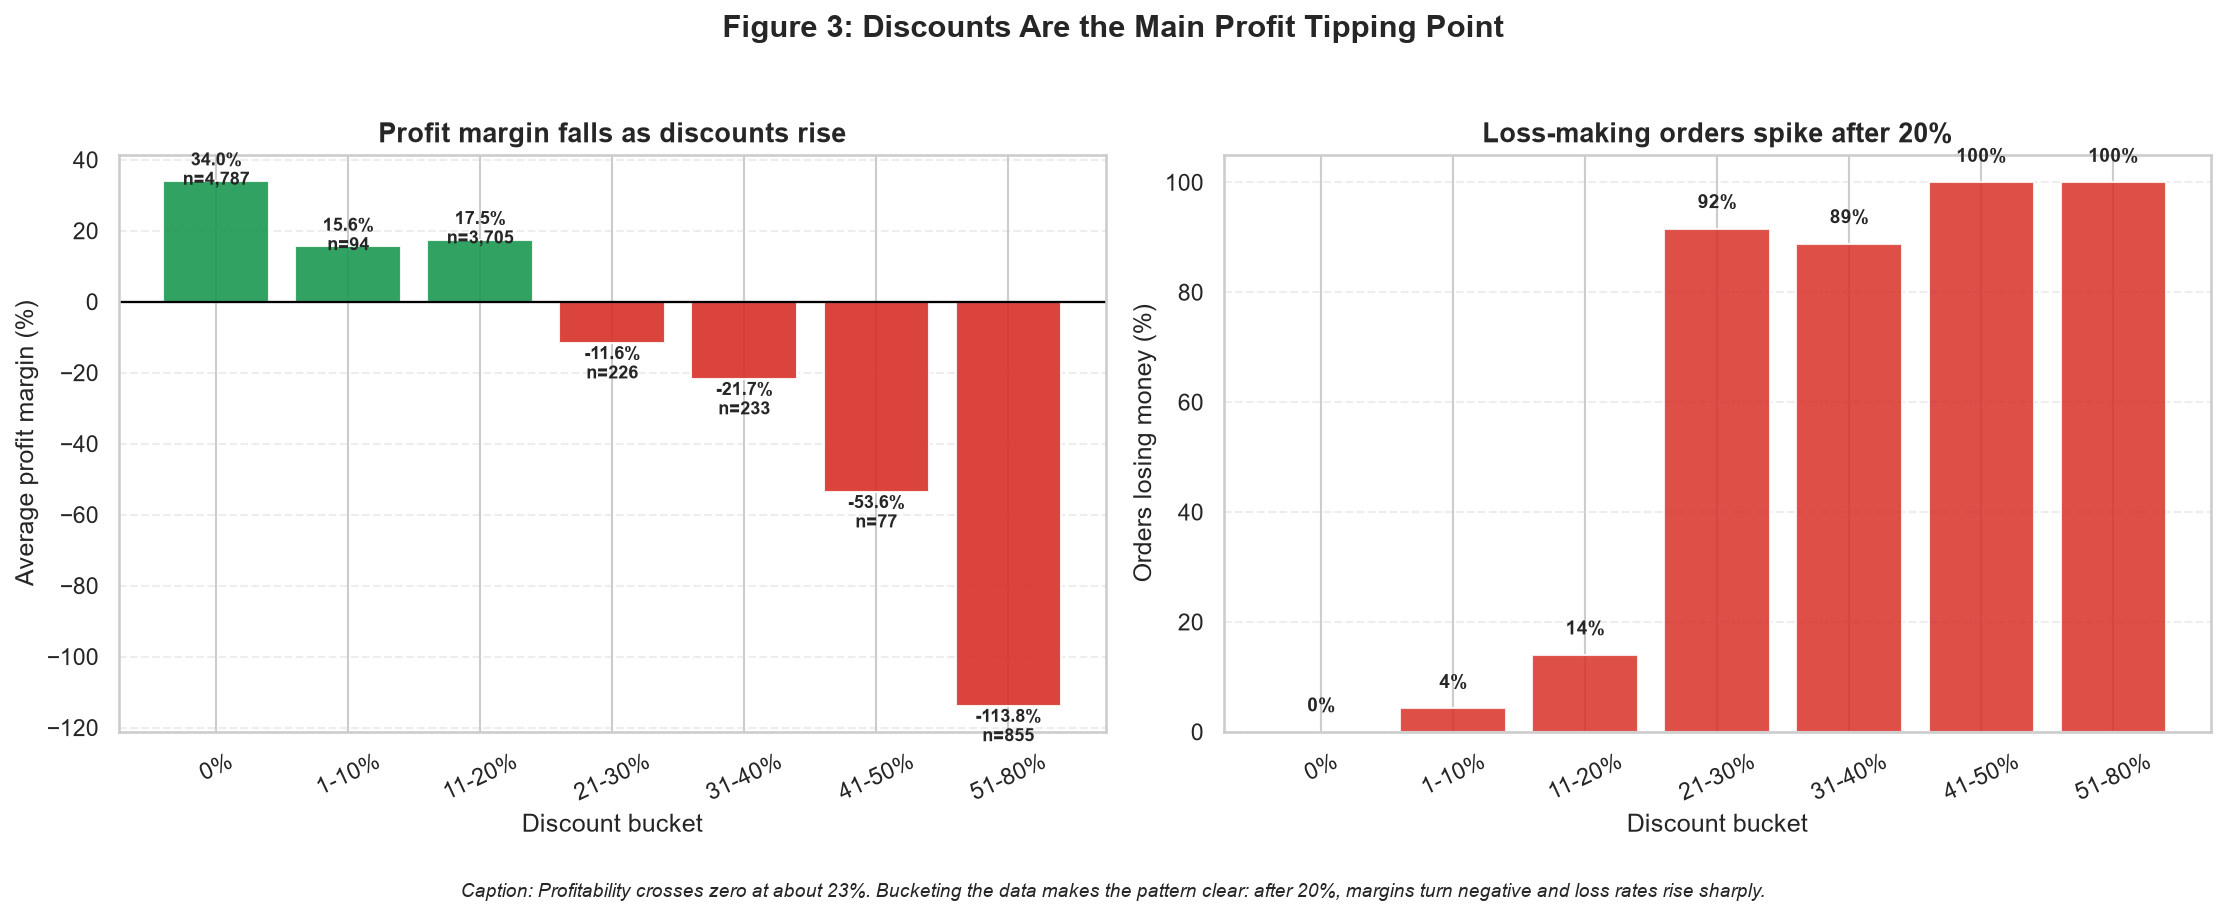

In [15]:
# Figure 3: show the discount problem with simple buckets instead of a dense scatter plot
df['Discount_Bucket'] = pd.cut(
    df['Discount'],
    bins=[-0.01, 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.8],
    labels=['0%', '1-10%', '11-20%', '21-30%', '31-40%', '41-50%', '51-80%']
)

bucket_stats = df.groupby('Discount_Bucket', observed=True).agg(
    Avg_Margin=('Profit_Margin', 'mean'),
    Order_Count=('Profit_Margin', 'size'),
    Loss_Rate=('Profit', lambda s: (s < 0).mean() * 100)
).reset_index()

# Estimate the zero-margin discount tipping point from a simple linear trend
plot_df = df[df['Profit_Margin'].between(-200, 200)].copy()
z = np.polyfit(plot_df['Discount'], plot_df['Profit_Margin'], 1)
tipping_discount = -z[1] / z[0]

print(f'Discount tipping point where margin crosses zero: ~{tipping_discount:.1%}')
print('\n--- Discount Bucket Summary ---')
print(bucket_stats.to_string(index=False, formatters={
    'Avg_Margin': '{:.1f}%'.format,
    'Loss_Rate': '{:.1f}%'.format
}))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: average margin by discount bucket
margin_colors = ['#1a9850' if v >= 0 else '#d73027' for v in bucket_stats['Avg_Margin']]
bars = axes[0].bar(bucket_stats['Discount_Bucket'].astype(str), bucket_stats['Avg_Margin'],
                   color=margin_colors, alpha=0.9)
axes[0].axhline(0, color='black', linewidth=1.1)
axes[0].set_title('Profit margin falls as discounts rise', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Discount bucket')
axes[0].set_ylabel('Average profit margin (%)')
axes[0].grid(axis='y', linestyle='--', alpha=0.35)
for bar, value, count in zip(bars, bucket_stats['Avg_Margin'], bucket_stats['Order_Count']):
    label_y = value + (3 if value >= 0 else -6)
    axes[0].text(bar.get_x() + bar.get_width()/2, label_y,
                 f'{value:.1f}%\nn={count:,}', ha='center', va='center', fontsize=8.5, fontweight='bold')

# Right: share of orders losing money by discount bucket
loss_bars = axes[1].bar(bucket_stats['Discount_Bucket'].astype(str), bucket_stats['Loss_Rate'],
                        color='#d73027', alpha=0.85)
axes[1].set_title('Loss-making orders spike after 20%', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Discount bucket')
axes[1].set_ylabel('Orders losing money (%)')
axes[1].set_ylim(0, 105)
axes[1].grid(axis='y', linestyle='--', alpha=0.35)
for bar, value in zip(loss_bars, bucket_stats['Loss_Rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2, value + 3,
                 f'{value:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

for ax in axes:
    ax.tick_params(axis='x', rotation=25)

plt.suptitle('Figure 3: Discounts Are the Main Profit Tipping Point', fontsize=15, fontweight='bold', y=1.03)
plt.figtext(0.5, -0.04,
            f'Caption: Profitability crosses zero at about {tipping_discount:.0%}. Bucketing the data makes the pattern clear: after 20%, margins turn negative and loss rates rise sharply.',
            wrap=True, horizontalalignment='center', fontsize=9, style='italic')
plt.tight_layout()
plt.show()


--- Bottom 5 & Top 5 Sub-Categories by Total Profit ---
Sub-Category Total_Sales Total_Profit Avg_Discount Avg_Margin
      Tables    $206,966     $-17,725        26.1%     -14.8%
   Bookcases    $114,880      $-3,473        21.1%     -12.7%
    Supplies     $46,674      $-1,189         7.7%      11.2%
   Fasteners      $3,024         $950         8.2%      29.9%
    Machines    $189,239       $3,385        30.6%      -7.2%
     Binders    $203,409      $30,228        37.2%     -19.9%
       Paper     $78,224      $33,944         7.5%      42.6%
 Accessories    $167,380      $41,937         7.8%      21.8%
      Phones    $330,007      $44,516        15.5%      11.9%
     Copiers    $149,528      $55,618        16.2%      31.7%


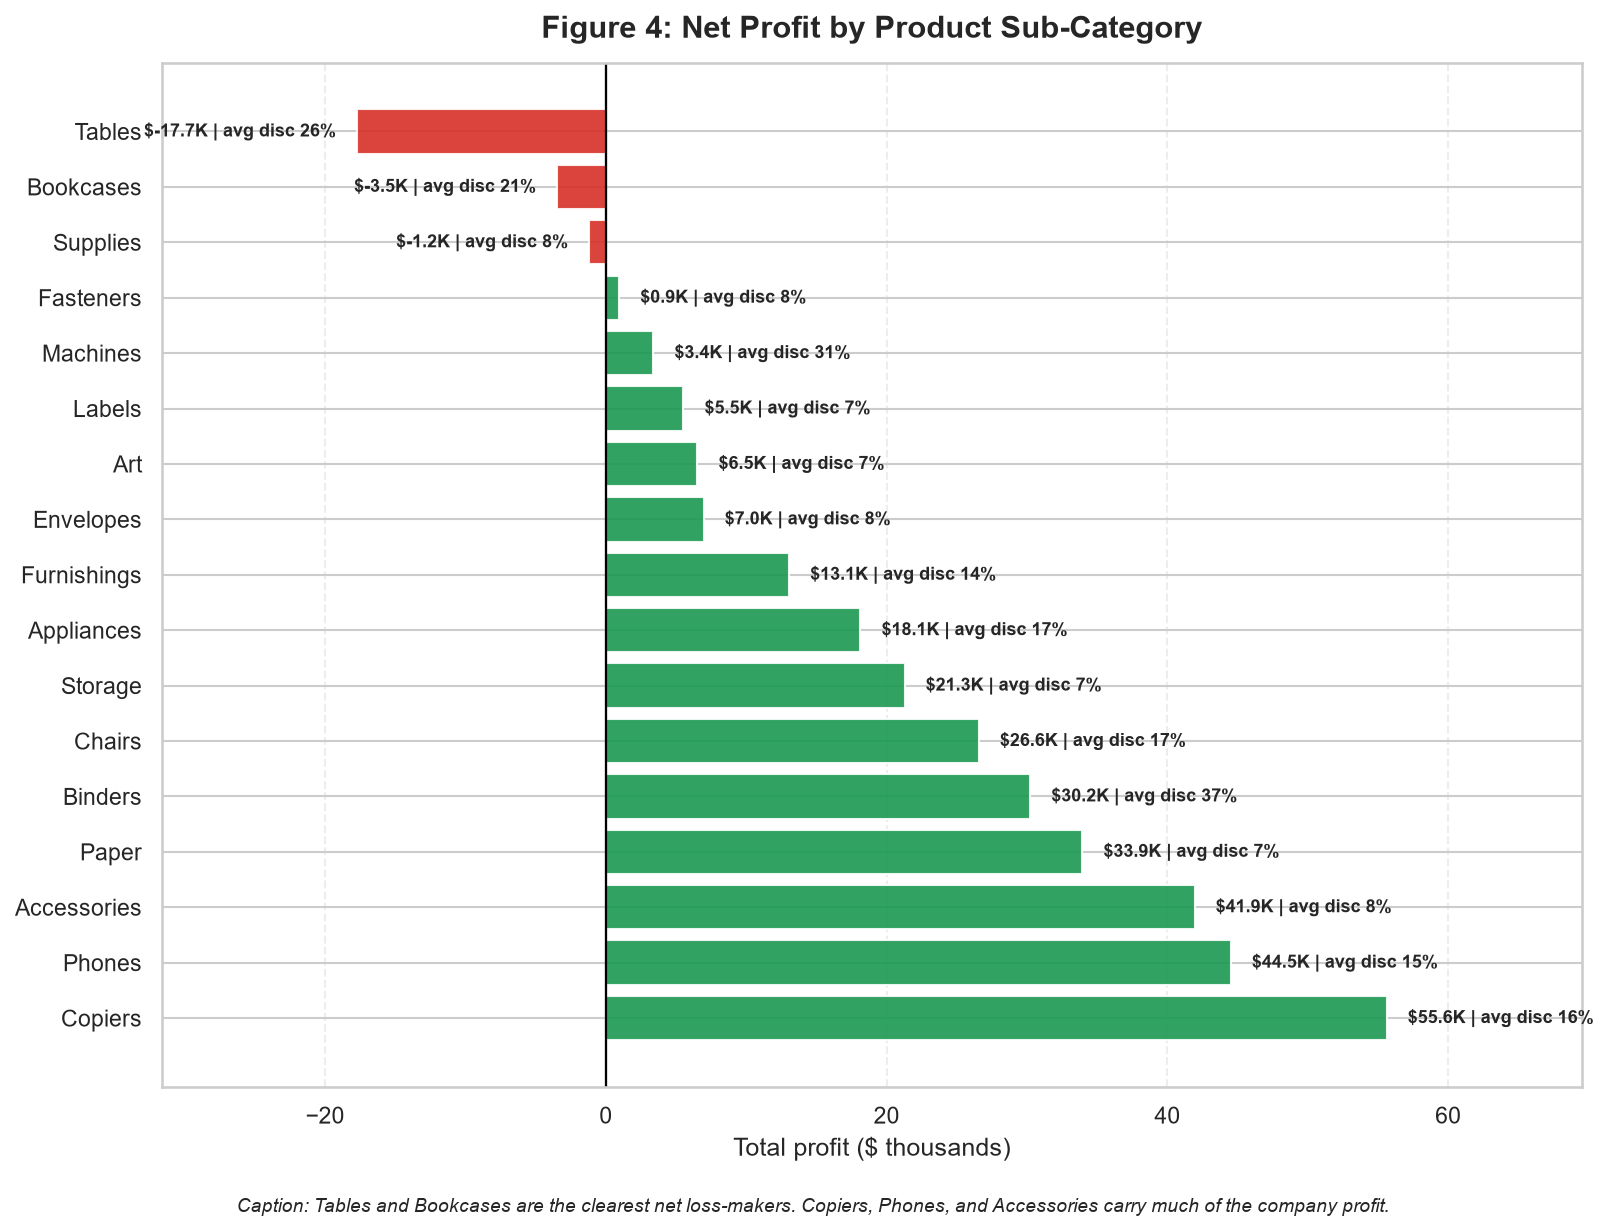

In [16]:
# Figure 4: rank sub-categories by total profit so winners and losers are obvious
subcat_summary = df.groupby('Sub-Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Discount=('Discount', 'mean'),
    Avg_Margin=('Profit_Margin', 'mean')
).reset_index()
subcat_summary = subcat_summary.sort_values('Total_Profit').reset_index(drop=True)

print('--- Bottom 5 & Top 5 Sub-Categories by Total Profit ---')
print(pd.concat([subcat_summary.head(5), subcat_summary.tail(5)]).to_string(index=False, formatters={
    'Total_Sales': '${:,.0f}'.format,
    'Total_Profit': '${:,.0f}'.format,
    'Avg_Discount': '{:.1%}'.format,
    'Avg_Margin': '{:.1f}%'.format
}))

fig, ax = plt.subplots(figsize=(11, 8))
colors = subcat_summary['Total_Profit'].apply(lambda v: '#d73027' if v < 0 else '#1a9850')
bars = ax.barh(subcat_summary['Sub-Category'], subcat_summary['Total_Profit'] / 1000,
               color=colors, alpha=0.9)
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=1.1)
ax.set_title('Figure 4: Net Profit by Product Sub-Category', fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel('Total profit ($ thousands)')
ax.set_ylabel('')
ax.grid(axis='x', linestyle='--', alpha=0.35)

for bar, profit, discount in zip(bars, subcat_summary['Total_Profit'], subcat_summary['Avg_Discount']):
    x_pos = bar.get_width()
    label_x = x_pos + (1.5 if profit >= 0 else -1.5)
    ha = 'left' if profit >= 0 else 'right'
    ax.text(label_x, bar.get_y() + bar.get_height()/2,
            f'${profit/1000:.1f}K | avg disc {discount:.0%}',
            va='center', ha=ha, fontsize=8.5, fontweight='bold')

min_profit = subcat_summary['Total_Profit'].min() / 1000
max_profit = subcat_summary['Total_Profit'].max() / 1000
padding = max(abs(min_profit), abs(max_profit)) * 0.25
ax.set_xlim(min_profit - padding, max_profit + padding)

plt.figtext(0.5, -0.02,
            'Caption: Tables and Bookcases are the clearest net loss-makers. Copiers, Phones, and Accessories carry much of the company profit.',
            wrap=True, horizontalalignment='center', fontsize=9, style='italic')
plt.tight_layout()
plt.show()


--- Pearson Correlation Matrix ---
               Sales  Quantity  Discount  Profit  Profit_Margin
Sales          1.000     0.201    -0.028   0.479          0.004
Quantity       0.201     1.000     0.009   0.066         -0.005
Discount      -0.028     0.009     1.000  -0.220         -0.864
Profit         0.479     0.066    -0.220   1.000          0.224
Profit_Margin  0.004    -0.005    -0.864   0.224          1.000


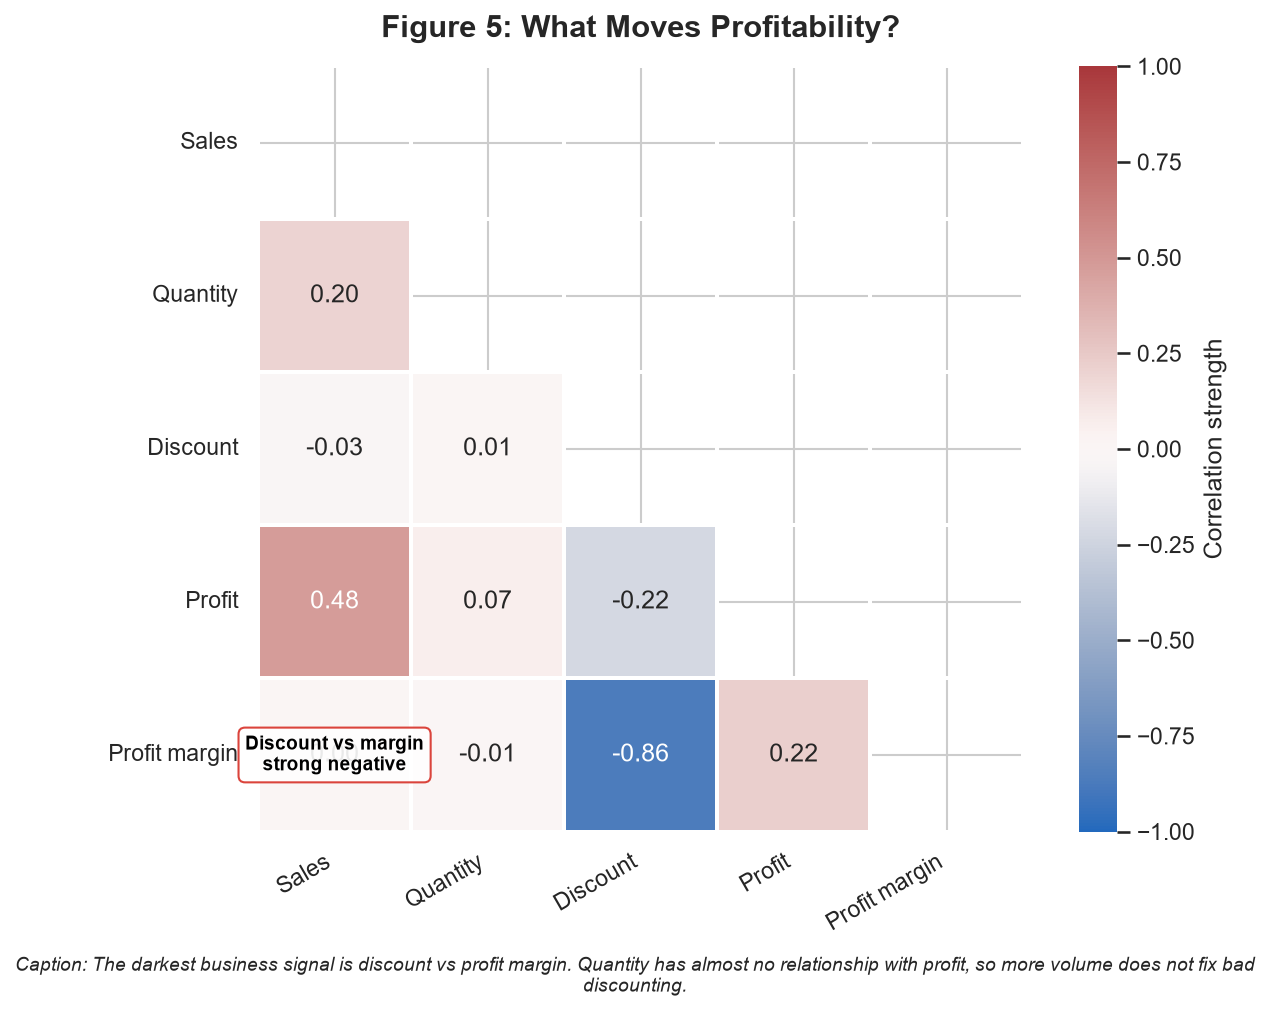

In [17]:
# Figure 5: readable correlation heatmap with business-friendly labels
corr_vars = ['Sales', 'Quantity', 'Discount', 'Profit', 'Profit_Margin']
corr_matrix = df[corr_vars].corr()

friendly_labels = {
    'Sales': 'Sales',
    'Quantity': 'Quantity',
    'Discount': 'Discount',
    'Profit': 'Profit',
    'Profit_Margin': 'Profit margin'
}
corr_display = corr_matrix.rename(index=friendly_labels, columns=friendly_labels)

print('--- Pearson Correlation Matrix ---')
print(corr_matrix.round(3))

plt.figure(figsize=(8.5, 6.5))
mask = np.triu(np.ones_like(corr_display, dtype=bool))
ax = sns.heatmap(
    corr_display,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='vlag',
    vmin=-1,
    vmax=1,
    linewidths=1,
    square=True,
    cbar_kws={'label': 'Correlation strength'}
)

ax.set_title('Figure 5: What Moves Profitability?', fontsize=15, fontweight='bold', pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# Call out the most important relationship in the story
ax.text(0.5, 4.5, 'Discount vs margin\nstrong negative',
        ha='center', va='center', fontsize=9, fontweight='bold', color='black',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#d73027', alpha=0.9))

plt.figtext(0.5, -0.03,
            'Caption: The darkest business signal is discount vs profit margin. Quantity has almost no relationship with profit, so more volume does not fix bad discounting.',
            wrap=True, horizontalalignment='center', fontsize=9, style='italic')
plt.tight_layout()
plt.show()


# Executive Data Story: The Discount Paradox - Rescuing Profitability in E-Commerce Retail

**Author:** Misiko  
**Dataset:** Sample Superstore (9,977 Cleaned Transactions)  
**Track:** Track I: AI Data Science - Gate I1  

---

### 1. Executive Summary & Problem Context
An analysis of 9,977 retail transactions revealed a clear operational paradox: the Superstore produced strong top-line revenue of **$2.29M**, but net profit reached only **$286K**. That means the business is not failing to sell; it is failing to protect margin.

Most importantly, **18.7% of all customer orders (1,869 transactions) lost money**. The evidence points to a focused cause: **discounts become destructive once they move beyond the low-20% range**.

---

### 2. Core Empirical Findings (Referencing Visual Evidence)

1. **Small Orders, Meaningful Loss Exposure (Figure 1):**
   Most orders are relatively small, with a median order value of about **$55**. However, the order-level profit snapshot shows that **1,869 orders** lost money. This makes the problem easy to understand: a large share of everyday transactions is quietly reducing profit.

2. **Category Profitability Divergence (Figure 2):**
   **Technology** generated about **$836K** in sales and delivered about **$145K** in profit, a strong **17.4% margin**. **Furniture** generated comparable revenue of about **$741K**, but returned only **$18K** in profit, a weak **2.5% margin**. Furniture is therefore a high-revenue but low-return category.

3. **The Discount Tipping Point (Figure 3):**
   Discount buckets reveal the root cause. At **0% discount**, average margin is about **+34.0%**. Between **11% and 20%**, margins remain positive at about **+17.5%**. But after roughly **22.9% discount**, profitability crosses below zero. Orders discounted above 50% average deeply negative margins.

4. **Sub-Category Winners and Losers (Figure 4):**
   Ranking sub-categories by total profit shows the business impact directly. **Tables** are the biggest net loss-maker at about **-$17.7K**, followed by **Bookcases** at about **-$3.5K**. On the profitable side, **Copiers**, **Phones**, and **Accessories** carry a large share of total profit.

5. **The Volume Fallacy (Figure 5):**
   The correlation heatmap confirms that discounting is the strongest profitability signal. Discount has a strong negative relationship with profit margin (**r = -0.864**), while quantity has almost no relationship with profit (**r = +0.066**). Selling more units does not fix unprofitable discounting.

---

### 3. Strategic & Actionable Recommendations

1. **Hard-Cap Discretionary Discounts at 20%:**  
   Because the empirical tipping point is about 22.9%, a 20% cap gives the business a practical safety buffer before promotions become loss-making.

2. **Re-Engineer Tables & Bookcases Pricing:**  
   Tables and Bookcases should receive immediate pricing review. Options include lower discount limits, supplier cost renegotiation, freight review, or bundling with higher-margin products.

3. **Incentivize Sales Teams on Net Profit, Not Gross Revenue:**  
   Revenue-focused incentives can reward deals that look large but destroy margin. Sales performance should include profit or margin targets so teams avoid closing high-discount, loss-making orders.
